# Speed Estimation System

---

## What Are We Building?

A system that estimates the **speed of each vehicle** passing a fixed road camera,
in addition to counting them.

```
Fixed Camera
     |
     v
 [Vehicle Tracking]        <- stable ID + position per frame (from Day 1)
     |
     v
 [Perspective Transform]   <- convert pixel coords to real-world metres
     |
     v
 [Speed Calculation]       <- distance / time = speed (km/h)
     |
     v
 [Count Per Minute]        <- rolling window count over 60 seconds
```

## Why Pixels Alone Are Not Enough

A vehicle moving 20 pixels per frame could be:
- A car at 60 km/h close to the camera, OR
- A truck at 120 km/h far from the camera

We need to convert pixels to real-world metres first.

## Topics
1. Pixel-to-Metre Conversion (perspective transform)
2. Speed Formula and Units
3. Count Per Minute (rolling window)
4. Complete Speed Estimation Pipeline
5. What I Learned

---
# Part 1: Pixel-to-Metre Conversion

## The Problem: Perspective Distortion

A road camera looks at the road at an angle.
One pixel near the top of the frame covers more real-world ground than one pixel near the bottom.

```
Camera view (top-down perspective):

  top of frame (far away)  ←  1 pixel = 0.5 metres
  ─────────────────────────
  ─────────────────────────
  bottom of frame (close)  ←  1 pixel = 0.05 metres
```

## Solution: Perspective Transform (Bird's Eye View)

We pick 4 known reference points on the road (e.g., lane markings whose real spacing we know)
and compute a **homography matrix** that warps the camera view into a top-down view
where 1 pixel = a fixed number of metres everywhere.

```python
# 4 points in the original camera frame (pixels)
src_pts = np.float32([[x1,y1], [x2,y2], [x3,y3], [x4,y4]])

# Where those 4 points map to in the bird's eye view (pixels)
dst_pts = np.float32([[0,0], [W,0], [0,H], [W,H]])

# Compute the transform
M = cv2.getPerspectiveTransform(src_pts, dst_pts)

# Warp a point from camera view to bird's eye view
point_warped = cv2.perspectiveTransform(point, M)
```

## Calibration: Pixels Per Metre

Once you have the bird's eye view, measure a known distance:
- A standard lane is 3.7 metres wide in most countries
- Standard road markings: dashes are 3m long, gaps are 9m

```python
# If lane width = 150 pixels in bird's eye view, and real lane = 3.7m
pixels_per_metre = 150 / 3.7   # = 40.5 px/m
metres_per_pixel = 3.7 / 150   # = 0.0247 m/px
```

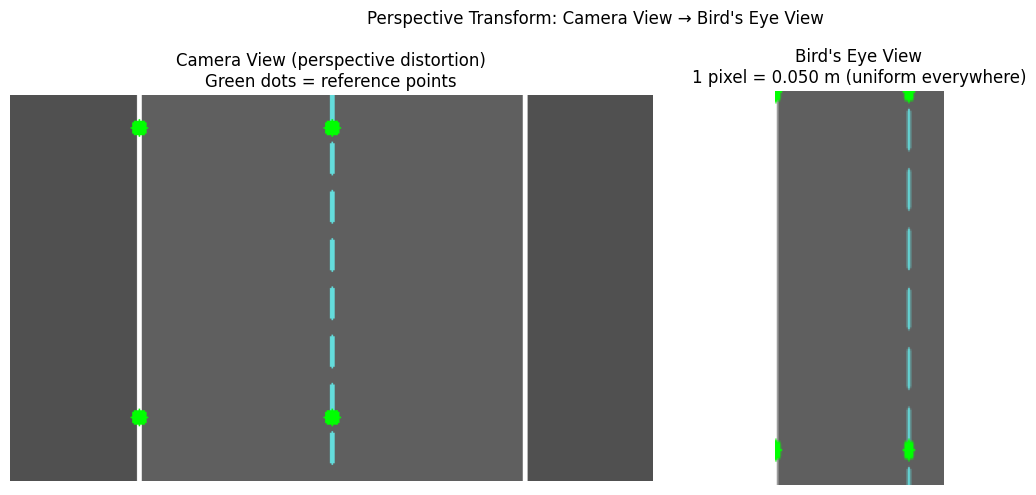

Lane width in bird eye view: 74 px = 3.7 m
Segment in bird eye view:    200 px = 10.0 m
Scale: 0.05 m/px


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Perspective transform demo ─────────────────────────────────────────────

H_FRAME, W_FRAME = 240, 400

def make_road_top_view():
    """Simulate a camera view of a two-lane road."""
    frame = np.ones((H_FRAME, W_FRAME, 3), dtype=np.uint8) * 80
    # Road
    cv2.rectangle(frame, (80, 0), (320, H_FRAME), (95, 95, 95), -1)
    # Lane markings (dashes)
    for y in range(0, H_FRAME, 30):
        cv2.line(frame, (200, y), (200, y+18), (220, 220, 100), 2)
    # Lane edges
    cv2.line(frame, (80,  0), (80,  H_FRAME), (255, 255, 255), 2)
    cv2.line(frame, (320, 0), (320, H_FRAME), (255, 255, 255), 2)
    # Known reference points (corners of one lane segment)
    ref_pts = np.array([[80, 20], [200, 20], [80, 200], [200, 200]], dtype=np.float32)
    for pt in ref_pts:
        cv2.circle(frame, tuple(pt.astype(int)), 5, (0, 255, 0), -1)
    return frame, ref_pts

frame, ref_pts = make_road_top_view()

# ── Define the perspective transform ─────────────────────────────────────
# src: reference points in camera view
src_pts = ref_pts

# dst: where those points go in bird's eye view
# Real dimensions: lane = 3.7m wide, segment = 10m long
# We set 1 pixel = 0.05 metres → lane = 74px wide, segment = 200px long
METRES_PER_PIXEL = 0.05
LANE_W_PX  = int(3.7  / METRES_PER_PIXEL)   # 74 pixels
SEGMENT_PX = int(10.0 / METRES_PER_PIXEL)   # 200 pixels

dst_pts = np.float32([
    [0,          0],
    [LANE_W_PX,  0],
    [0,          SEGMENT_PX],
    [LANE_W_PX,  SEGMENT_PX],
])

M   = cv2.getPerspectiveTransform(src_pts, dst_pts)
M_inv = cv2.getPerspectiveTransform(dst_pts, src_pts)

bird_eye = cv2.warpPerspective(frame, M, (LANE_W_PX + 20, SEGMENT_PX + 20))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Camera View (perspective distortion)\nGreen dots = reference points')
axes[1].imshow(cv2.cvtColor(bird_eye, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Bird's Eye View\n1 pixel = {METRES_PER_PIXEL:.3f} m (uniform everywhere)")
for ax in axes: ax.axis('off')
plt.suptitle('Perspective Transform: Camera View → Bird\'s Eye View', fontsize=12)
plt.tight_layout()
plt.savefig('perspective_transform.png', dpi=100)
plt.show()
print(f'Lane width in bird eye view: {LANE_W_PX} px = 3.7 m')
print(f'Segment in bird eye view:    {SEGMENT_PX} px = 10.0 m')
print(f'Scale: {METRES_PER_PIXEL} m/px')

---
# Part 2: Speed Formula and Units

## The Formula

$$\text{speed} = \frac{\text{distance}}{\text{time}}$$

For a vehicle tracked across frames:

$$v \, [\text{m/s}] = \frac{d_{metres}}{\Delta t_{seconds}}$$

$$v \, [\text{km/h}] = v \, [\text{m/s}] \times 3.6$$

## Step by Step

1. Take position at frame $t_1$: pixel $(x_1, y_1)$
2. Take position at frame $t_2$: pixel $(x_2, y_2)$
3. Warp both points to bird's eye view
4. Compute Euclidean distance in pixels: $d_{px} = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$
5. Convert to metres: $d_m = d_{px} \times \text{metres\_per\_pixel}$
6. Time elapsed: $\Delta t = \frac{t_2 - t_1}{\text{fps}}$ seconds
7. Speed: $v = (d_m / \Delta t) \times 3.6$ km/h

## Smoothing the Speed Estimate

A single frame-to-frame measurement is very noisy.
Better approaches:

**Method 1: Moving average over N frames**
```python
speed_buffer.append(current_speed)
if len(speed_buffer) > N:
    speed_buffer.pop(0)
smooth_speed = sum(speed_buffer) / len(speed_buffer)
```

**Method 2: Speed from Kalman filter velocity state**
```python
# Kalman state = [x, y, vx, vy]
vx_pixels = kalman.statePost[2, 0]   # pixels/frame
vy_pixels = kalman.statePost[3, 0]
speed_px_per_frame = math.sqrt(vx_pixels**2 + vy_pixels**2)
speed_m_per_s = speed_px_per_frame * metres_per_pixel * fps
speed_kmh = speed_m_per_s * 3.6
```

Method 2 is better because the Kalman velocity is already smoothed.

FPS=25 | metres_per_pixel=0.05

vx (px/frame)      vy (px/frame)      Speed (km/h)    Description
---------------------------------------------------------------------------
8                  0                  36.0            Car at 60 km/h (horizontal motion)
12                 0                  54.0            Car at 90 km/h
16                 0                  72.0            Car at 120 km/h
6                  4                  32.4            Car at ~60 km/h (diagonal motion)


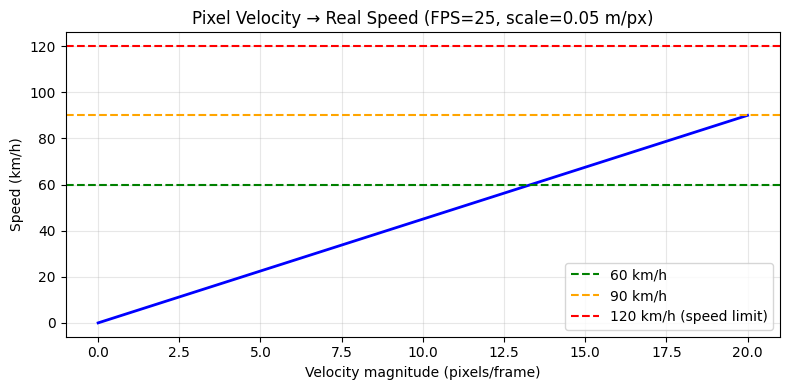

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ── Speed calculation demo ─────────────────────────────────────────────────

FPS = 25
METRES_PER_PIXEL = 0.05

def pixel_speed_to_kmh(vx_px_frame, vy_px_frame, mpp, fps):
    """
    Convert Kalman velocity (pixels/frame) to km/h.
    vx_px_frame: horizontal pixels per frame
    vy_px_frame: vertical pixels per frame
    mpp: metres per pixel (from calibration)
    fps: camera frames per second
    """
    speed_px_per_frame = math.sqrt(vx_px_frame**2 + vy_px_frame**2)
    speed_m_per_s = speed_px_per_frame * mpp * fps
    speed_kmh = speed_m_per_s * 3.6
    return speed_kmh

# Example: a vehicle moving 8 pixels/frame horizontally
test_cases = [
    (8,  0, 'Car at 60 km/h (horizontal motion)'),
    (12, 0, 'Car at 90 km/h'),
    (16, 0, 'Car at 120 km/h'),
    (6,  4, 'Car at ~60 km/h (diagonal motion)'),
]

print(f'FPS={FPS} | metres_per_pixel={METRES_PER_PIXEL}')
print()
print(f'{"vx (px/frame)":<18} {"vy (px/frame)":<18} {"Speed (km/h)":<15} Description')
print('-' * 75)
for vx, vy, desc in test_cases:
    kmh = pixel_speed_to_kmh(vx, vy, METRES_PER_PIXEL, FPS)
    print(f'{vx:<18} {vy:<18} {kmh:<15.1f} {desc}')

# Visualize: speed vs velocity magnitude
vx_range = np.linspace(0, 20, 100)
speeds = [pixel_speed_to_kmh(vx, 0, METRES_PER_PIXEL, FPS) for vx in vx_range]

plt.figure(figsize=(8, 4))
plt.plot(vx_range, speeds, 'b-', lw=2)
plt.axhline(60,  color='green',  ls='--', label='60 km/h')
plt.axhline(90,  color='orange', ls='--', label='90 km/h')
plt.axhline(120, color='red',    ls='--', label='120 km/h (speed limit)')
plt.xlabel('Velocity magnitude (pixels/frame)')
plt.ylabel('Speed (km/h)')
plt.title('Pixel Velocity → Real Speed (FPS=25, scale=0.05 m/px)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('speed_conversion.png', dpi=100)
plt.show()

---
# Part 3: Count Per Minute (Rolling Window)

## What Is Count Per Minute?

Instead of just total count, traffic analysts want to know how many vehicles
pass per minute — this is the **traffic flow rate**.

## Rolling Window Method

Keep a list of timestamps of every crossing event.
At any moment, count how many events happened in the last 60 seconds.

```python
import time
from collections import deque

crossing_times = deque()   # timestamps of each vehicle crossing

def record_crossing():
    crossing_times.append(time.time())

def count_per_minute():
    now = time.time()
    # Remove events older than 60 seconds
    while crossing_times and crossing_times[0] < now - 60:
        crossing_times.popleft()
    return len(crossing_times)   # vehicles in the last 60 seconds
```

## For Video Files (Frame-Based Timestamps)

When processing a video file there is no real clock, so we compute time from frame number:

```python
time_seconds = frame_number / fps
```

Then the rolling window works the same way.

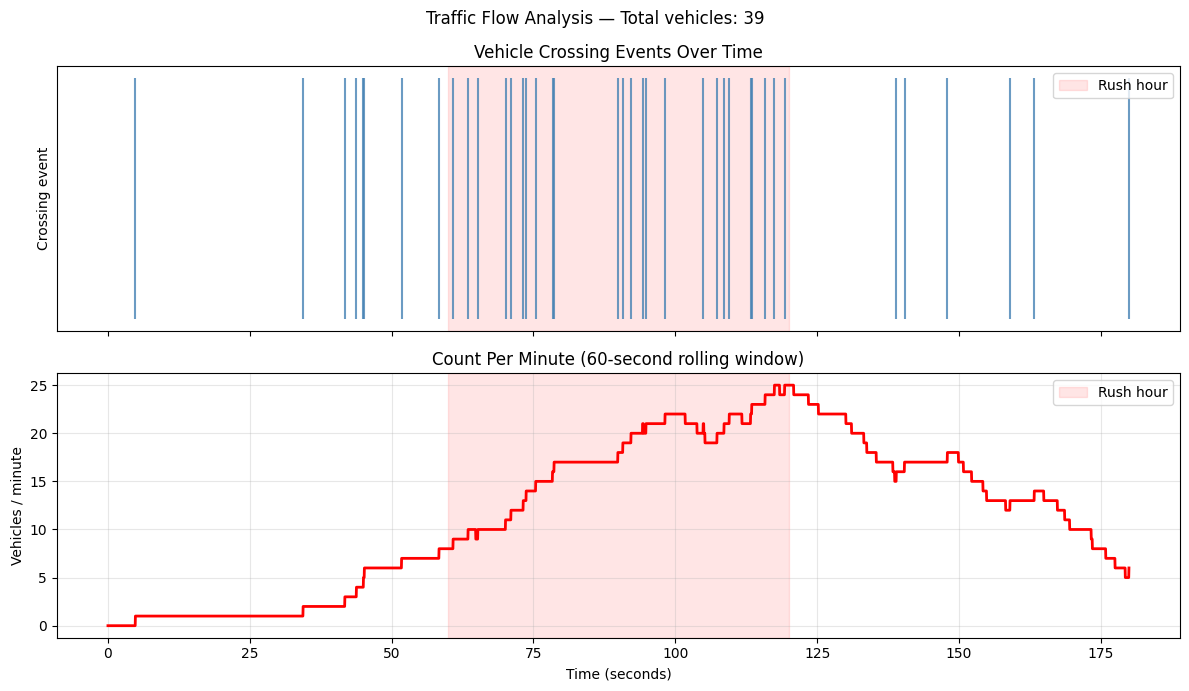

Total vehicles:    39
Peak flow rate:    25 vehicles/minute
Average flow rate: 13.0 vehicles/minute


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ── Count-per-minute rolling window demo ──────────────────────────────────

FPS = 25
TOTAL_FRAMES = 25 * 180   # 3 minutes of video

# Simulate crossing events (random vehicle arrivals, more during rush hour)
np.random.seed(42)
crossings = []   # frame numbers when vehicles cross

# Sparse traffic: frames 0-1500 (0-60s)
for _ in range(8):
    crossings.append(np.random.randint(0, 1500))

# Rush hour: frames 1500-3000 (60-120s)
for _ in range(25):
    crossings.append(np.random.randint(1500, 3000))

# Light traffic: frames 3000-4500 (120-180s)
for _ in range(6):
    crossings.append(np.random.randint(3000, 4500))

crossings.sort()

# Compute count-per-minute at every frame
crossing_times = deque()
cpm_history = []
total_count = 0
crossing_set = set(crossings)

for frame_idx in range(TOTAL_FRAMES):
    t = frame_idx / FPS   # time in seconds

    if frame_idx in crossing_set:
        total_count += 1
        crossing_times.append(t)

    # Remove events older than 60 seconds
    while crossing_times and crossing_times[0] < t - 60:
        crossing_times.popleft()

    cpm_history.append(len(crossing_times))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

times = np.arange(TOTAL_FRAMES) / FPS

# Top: crossing events
axes[0].vlines([c/FPS for c in crossings], 0, 1, color='steelblue', alpha=0.8)
axes[0].set_ylabel('Crossing event')
axes[0].set_title('Vehicle Crossing Events Over Time')
axes[0].set_yticks([])
axes[0].axvspan(60, 120, alpha=0.1, color='red', label='Rush hour')
axes[0].legend()

# Bottom: count per minute
axes[1].plot(times, cpm_history, 'r-', lw=2)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Vehicles / minute')
axes[1].set_title('Count Per Minute (60-second rolling window)')
axes[1].axvspan(60, 120, alpha=0.1, color='red', label='Rush hour')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Traffic Flow Analysis — Total vehicles: {total_count}', fontsize=12)
plt.tight_layout()
plt.savefig('count_per_minute.png', dpi=100)
plt.show()

peak_cpm = max(cpm_history)
print(f'Total vehicles:    {total_count}')
print(f'Peak flow rate:    {peak_cpm} vehicles/minute')
print(f'Average flow rate: {total_count / (TOTAL_FRAMES/FPS/60):.1f} vehicles/minute')

---
# Part 4: Complete Speed Estimation Pipeline

This combines the vehicle counter from Day 1 with speed estimation.

**Key additions:**
- Each `KalmanTracker` provides velocity `[vx, vy]` from its state vector
- We convert that velocity to km/h using the pixel calibration
- We display speed next to each bounding box
- We log: timestamp, vehicle ID, speed, direction

To run on a real highway video clip:
```python
run_speed_estimator(source='highway.mp4', fps=25, metres_per_pixel=0.05)
```

In [4]:
import cv2, numpy as np, math, csv, datetime, os
from collections import deque, OrderedDict

# ── Re-use KalmanCentroidTracker from Day 1 ───────────────────────────────
# (paste the class here or import from day 1)

class KalmanTracker:
    def __init__(self, cx, cy):
        self.kf = cv2.KalmanFilter(4, 2)
        self.kf.transitionMatrix  = np.array([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]], np.float32)
        self.kf.measurementMatrix = np.array([[1,0,0,0],[0,1,0,0]], np.float32)
        self.kf.processNoiseCov   = np.eye(4, dtype=np.float32) * 0.03
        self.kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 2.0
        self.kf.errorCovPost      = np.eye(4, dtype=np.float32)
        self.kf.statePost         = np.array([[cx],[cy],[0],[0]], dtype=np.float32)
        self.disappeared = 0
        self.history = [(cx, cy)]
        self.speeds  = []    # speed history for smoothing

    def predict(self):
        pred = self.kf.predict()
        return int(pred[0,0]), int(pred[1,0])

    def correct(self, cx, cy):
        m = np.array([[cx],[cy]], dtype=np.float32)
        c = self.kf.correct(m)
        pos = (int(c[0,0]), int(c[1,0]))
        self.history.append(pos)
        return pos

    def get_speed_kmh(self, mpp, fps, smooth_n=5):
        """Compute speed from Kalman velocity state."""
        vx = float(self.kf.statePost[2, 0])
        vy = float(self.kf.statePost[3, 0])
        speed_px_frame = math.sqrt(vx**2 + vy**2)
        speed_kmh = speed_px_frame * mpp * fps * 3.6
        self.speeds.append(speed_kmh)
        if len(self.speeds) > smooth_n:
            self.speeds.pop(0)
        return sum(self.speeds) / len(self.speeds)  # smoothed


def run_speed_estimator(source=0, fps=25, metres_per_pixel=0.05,
                         line_x=None, line_y=None, min_area=1500,
                         max_disappeared=8, max_distance=80):
    """
    Vehicle counter + speed estimator.
    source: 0 (webcam) or path to video file.
    fps: frames per second of the video.
    metres_per_pixel: calibration (measure from known road markings).
    line_x/line_y: counting line position.
    """
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        print('ERROR: Cannot open source:', source)
        return

    fw = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    fh = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    actual_fps = cap.get(cv2.CAP_PROP_FPS) or fps

    # Counting line defaults
    if line_x is None and line_y is None:
        line_y = fh // 2

    # Components
    bg_sub   = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=60, detectShadows=True)
    kern     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    trackers = OrderedDict()
    next_id  = 0

    # Counters
    prev_pos      = {}
    counted       = set()
    count_fwd     = 0
    count_bwd     = 0
    crossing_times = deque()
    trails        = {}
    speed_log     = []
    frame_idx     = 0

    print(f'Speed Estimator running. Source={source} | FPS={actual_fps:.0f} | {fw}x{fh}')
    print(f'Scale: {metres_per_pixel} m/px | Press Q to quit.')

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1
        t_sec = frame_idx / actual_fps

        # ── BG subtraction ──
        raw = bg_sub.apply(frame)
        _, fg = cv2.threshold(raw, 200, 255, cv2.THRESH_BINARY)
        fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN,  kern)
        fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kern)
        fg = cv2.dilate(fg, kern, iterations=2)

        # ── Contour detection ──
        cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        dets = []
        for cnt in cnts:
            if cv2.contourArea(cnt) < min_area: continue
            M = cv2.moments(cnt)
            if M['m00'] == 0: continue
            dets.append((int(M['m10']/M['m00']), int(M['m01']/M['m00'])))

        # ── Kalman tracking (simplified inline) ──
        predicted = {oid: t.predict() for oid, t in trackers.items()}
        result = {}
        if dets and trackers:
            det_arr  = np.array(dets, dtype=float)
            pred_arr = np.array(list(predicted.values()), dtype=float)
            D = np.linalg.norm(pred_arr[:,None,:] - det_arr[None,:,:], axis=2)
            rows = D.min(axis=1).argsort()
            cols = D.argmin(axis=1)[rows]
            used_r, used_c = set(), set()
            for r, c in zip(rows, cols):
                if r in used_r or c in used_c: continue
                if D[r,c] > max_distance: continue
                oid = list(trackers.keys())[r]
                result[oid] = trackers[oid].correct(*dets[c])
                trackers[oid].disappeared = 0
                used_r.add(r); used_c.add(c)
            for r in set(range(len(trackers))) - used_r:
                oid = list(trackers.keys())[r]
                trackers[oid].disappeared += 1
                if trackers[oid].disappeared > max_disappeared:
                    del trackers[oid]
                else:
                    result[oid] = predicted[oid]
            for c in set(range(len(dets))) - used_c:
                trackers[next_id] = KalmanTracker(*dets[c])
                result[next_id]   = dets[c]
                next_id += 1
        elif dets:
            for cx, cy in dets:
                trackers[next_id] = KalmanTracker(cx, cy)
                result[next_id]   = (cx, cy)
                next_id += 1
        else:
            for oid in list(trackers):
                trackers[oid].disappeared += 1
                if trackers[oid].disappeared > max_disappeared:
                    del trackers[oid]
                else:
                    result[oid] = predicted.get(oid, (0,0))

        # ── Counting + speed logging ──
        while crossing_times and crossing_times[0] < t_sec - 60:
            crossing_times.popleft()

        for oid, (cx, cy) in result.items():
            if oid in prev_pos and oid not in counted:
                px, py = prev_pos[oid]
                if line_y and py < line_y <= cy:
                    count_fwd += 1; counted.add(oid)
                    crossing_times.append(t_sec)
                    spd = trackers[oid].get_speed_kmh(metres_per_pixel, actual_fps)
                    speed_log.append({'id': oid, 'time': t_sec, 'speed_kmh': round(spd,1), 'dir': 'fwd'})
                elif line_y and py >= line_y > cy:
                    count_bwd += 1; counted.add(oid)
                    crossing_times.append(t_sec)
                    spd = trackers[oid].get_speed_kmh(metres_per_pixel, actual_fps)
                    speed_log.append({'id': oid, 'time': t_sec, 'speed_kmh': round(spd,1), 'dir': 'bwd'})
            prev_pos[oid] = (cx, cy)
            trails.setdefault(oid, []).append((cx, cy))
            if len(trails[oid]) > 40: trails[oid].pop(0)

        # ── Draw ──
        display = frame.copy()
        if line_y:
            cv2.line(display, (0, line_y), (fw, line_y), (0,255,255), 2)
        total = count_fwd + count_bwd
        cpm   = len(crossing_times)
        cv2.putText(display, f'COUNT:{total}  CPM:{cpm}', (10,30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

        for oid, (cx, cy) in result.items():
            trail = trails.get(oid,[])
            for j in range(1, len(trail)):
                cv2.line(display, trail[j-1], trail[j], (0,140,255), 2)
            spd = trackers[oid].get_speed_kmh(metres_per_pixel, actual_fps) if oid in trackers else 0
            color = (0,255,0) if spd < 90 else (0,165,255) if spd < 120 else (0,0,255)
            cv2.circle(display, (cx,cy), 6, color, -1)
            cv2.putText(display, f'{spd:.0f}km/h', (cx+8, cy-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        cv2.imshow('Speed Estimator', display)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

    cap.release()
    cv2.destroyAllWindows()

    # Print speed log
    print(f'\n=== Speed Log ===')
    print(f'{"ID":<6} {"Time(s)":<10} {"Speed(km/h)":<14} Dir')
    print('-' * 35)
    for entry in speed_log:
        print(f"{entry['id']:<6} {entry['time']:<10.1f} {entry['speed_kmh']:<14} {entry['dir']}")
    if speed_log:
        avg_spd = sum(e['speed_kmh'] for e in speed_log) / len(speed_log)
        print(f'\nAverage speed: {avg_spd:.1f} km/h')
    print(f'Total vehicles: {count_fwd + count_bwd}')


# run_speed_estimator(source='highway.mp4', fps=25, metres_per_pixel=0.05)
print('run_speed_estimator() defined.')
print('Call it with source=0 (webcam) or source="highway.mp4".')

run_speed_estimator() defined.
Call it with source=0 (webcam) or source="highway.mp4".


---
# What I Learned

I learned how to estimate vehicle speed from a road camera.

The most important thing I understood is that pixel distance alone means nothing for speed.
One pixel near the top of a camera frame covers much more real-world ground than one pixel near the bottom
because of perspective distortion. To fix this I use a perspective transform that warps the camera view
into a bird's eye view where one pixel always equals a fixed number of metres.
I calibrate this by measuring a known distance in the frame, like a lane width which is 3.7 metres.

I learned the speed formula: distance divided by time.
For a tracked vehicle I get the velocity directly from the Kalman filter state vector,
which already stores vx and vy in pixels per frame.
I multiply by metres per pixel to get metres per frame, then multiply by FPS to get metres per second,
then multiply by 3.6 to get km/h.
I also average the speed over the last 5 frames to remove noise.

I learned about count per minute, which is a rolling window counter.
I keep a queue of timestamps of each crossing event and count how many happened in the last 60 seconds.
This gives traffic engineers the flow rate, not just the total count.

I put everything together into one function that reads from a webcam or video file
and shows the speed next to each vehicle in different colours: green for under 90, orange for under 120,
red for over 120 km/h.